In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("Target classes:", data.target_names)

Dataset shape: (569, 30)
Target classes: ['malignant' 'benign']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [4]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [5]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
mean perimeter          0.069574
mean radius             0.068676
mean concavity          0.057638
mean area               0.049172
worst concavity         0.034340
dtype: float64


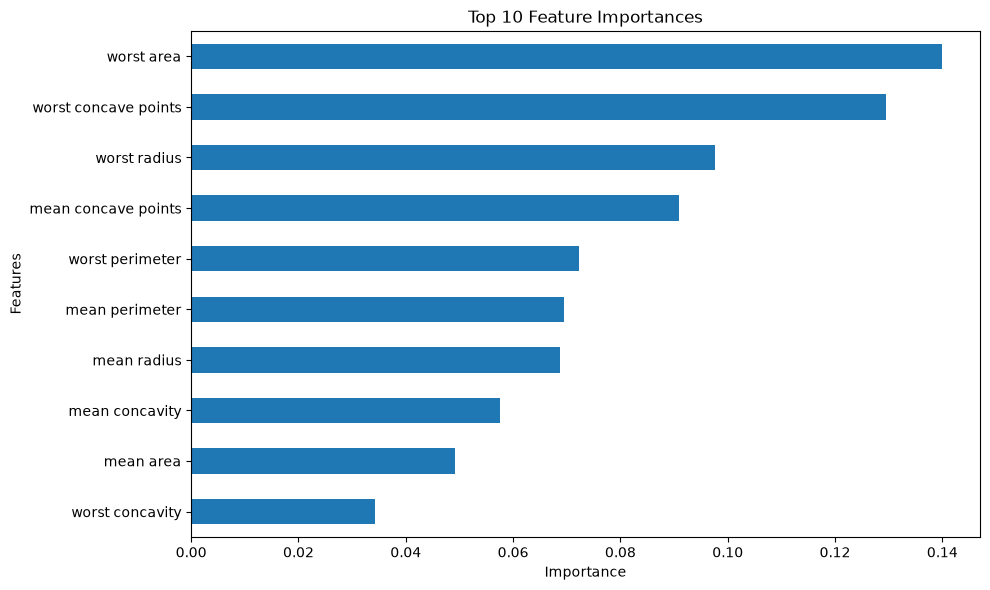

In [6]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [7]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


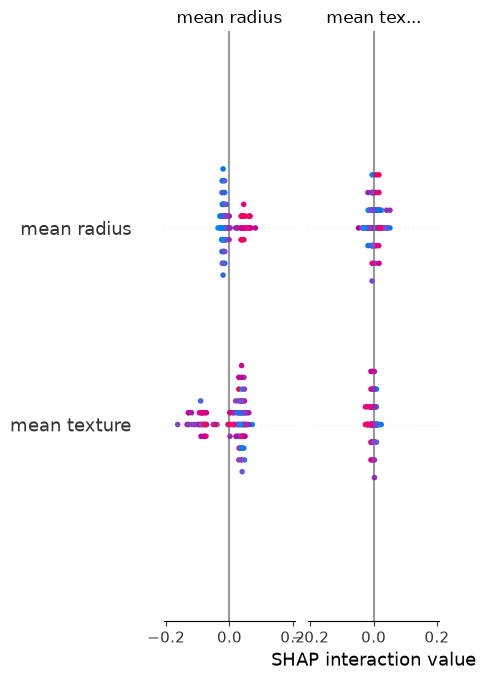

In [8]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

In [ ]:
## Bias and Fairness Analysis

The dataset used in this project does not contain demographic attributes such as age, gender, race, or socioeconomic information. Therefore, demographic fairness metrics could not be directly calculated.

However, model performance should still be monitored across relevant patient groups when such information is available. Using a more diverse dataset with appropriate demographic attributes would allow a more complete fairness evaluation.


In [ ]:
## Responsible AI Recommendations

1. Use diverse and representative datasets.
2. Evaluate model performance across relevant demographic groups when data is available.
3. Monitor false positives and false negatives because both can have important consequences in medical applications.
4. Use explainability techniques such as SHAP to understand model predictions.
5. Human experts should review model predictions before making medical decisions.
6. Protect patient privacy and handle medical data securely.
7. Continuously monitor and validate the model after deployment.

In [ ]:
## Conclusion

This project explored responsible AI and model interpretation using a Random Forest classification model.

Feature importance was used to identify the features that contributed most to the model. SHAP was also used to provide a more detailed explanation of model predictions.

The analysis demonstrates that model accuracy alone is not sufficient, especially for sensitive applications such as healthcare. Explainability, fairness, privacy, human oversight, and continuous monitoring are important considerations when developing responsible AI systems.

The absence of demographic information in the dataset limits the fairness analysis. Future work should use more diverse datasets containing appropriate demographic information to perform a comprehensive fairness evaluation.